# 1.4 Reddit: NLP — LDA Topic Modeling

This notebook applies Latent Dirichlet Allocation (LDA) to Reddit silver-layer data to uncover latent discussion topics across buzz groups and subreddits.

Four complementary analyses:
1. **Preprocessing** — tokenisation and stop-word filtering for LDA
2. **LDA topic modeling — posts** — topic discovery, coherence selection, temporal dynamics
3. **LDA topic modeling — comments** — topic comparison across posts and comments
4. **Subreddit echo chambers** — topic entropy and community-level alignment

**Input:** `Data/2_Silver/Reddit/reddit_posts_clean.parquet` · `reddit_comments_clean.parquet`

<!-- toc -->
## Contents
- [Setup](#setup)
- [1. Preprocessing](#1-preprocessing)
- [2. LDA Topic Modeling — Posts](#2-lda-topic-modeling--posts)
  - [2a. Build Dictionary & Corpus](#2a-build-dictionary--corpus)
  - [2b. Coherence Score: choosing optimal topics](#2b-coherence-score-choosing-optimal-topics)
  - [2c. Train Final Model](#2c-train-final-model)
  - [2d. Topic Prominence Over Time](#2d-topic-prominence-over-time)
  - [2e. Topic Distribution per Buzz Group](#2e-topic-distribution-per-buzz-group)
- [3. LDA Topic Modeling — Comments](#3-lda-topic-modeling--comments)
- [4. Subreddit Echo Chambers](#4-subreddit-echo-chambers)


## Setup

In [1]:
import os
import sys
import time
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Navigate to project root so Data/ paths resolve correctly
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '../..'))
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

# House style
from house_style import *
apply_style()

# LDA
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

# NLTK
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('punkt',       quiet=True)
nltk.download('punkt_tab',   quiet=True)
nltk.download('stopwords',   quiet=True)

from scipy.stats import entropy as scipy_entropy
import matplotlib.patches as mpatches
from wordcloud import WordCloud

STOP_WORDS = set(stopwords.words('english'))

print(f'Working directory: {os.getcwd()}')
print('Libraries imported successfully!')

Working directory: c:\Users\ninav\OneDrive - UGent\Unif\2025-2026\Semester 2\Social Media and Web Analytics\group-project-SMWA
Libraries imported successfully!


In [2]:
# ── Load Silver data ──────────────────────────────────────────────────────────
posts    = pd.read_parquet('./Data/2_Silver/Reddit/reddit_posts_clean.parquet')
comments = pd.read_parquet('./Data/2_Silver/Reddit/reddit_comments_clean.parquet')

# Normalise timestamps to date-level UTC
posts['date']    = pd.to_datetime(posts['created_utc'],    utc=True).dt.normalize()
comments['date'] = pd.to_datetime(comments['created_utc'], utc=True).dt.normalize()

# Fill NaN text
posts['text_clean']    = posts['text_clean'].fillna('')
comments['text_clean'] = comments['text_clean'].fillna('')

# ── Remove duplicate texts ─────────────────────────────────────────────────────
# IDs are unique, but text_clean contains duplicates from cross-posting and bots.
# We keep the first occurrence (highest score / earliest, as data is sorted).
n_posts_raw    = len(posts)
n_comments_raw = len(comments)

posts    = posts.drop_duplicates(subset='text_clean', keep='first').reset_index(drop=True)
comments = comments.drop_duplicates(subset='text_clean', keep='first').reset_index(drop=True)

print(f'Posts    : {n_posts_raw:,} -> {len(posts):,} rows  ({n_posts_raw - len(posts):,} duplicates removed)')
print(f'Comments : {n_comments_raw:,} -> {len(comments):,} rows  ({n_comments_raw - len(comments):,} duplicates removed)')
print(f'Date range posts    : {posts["date"].min().date()} -> {posts["date"].max().date()}')
print(f'Date range comments : {comments["date"].min().date()} -> {comments["date"].max().date()}')
print()
print('Posts by candidate:')
print(posts['candidate'].value_counts().to_string())
print()
print('Comments by candidate:')
print(comments['candidate'].value_counts().to_string())

Posts    : 105,017 -> 85,554 rows  (19,463 duplicates removed)
Comments : 1,376,013 -> 1,307,510 rows  (68,503 duplicates removed)
Date range posts    : 2024-07-05 -> 2024-11-03
Date range comments : 2024-07-05 -> 2024-11-03

Posts by candidate:
candidate
TrumpBuzz       34503
HarrisBuzz      30159
ElectionBuzz    20892

Comments by candidate:
candidate
TrumpBuzz       449556
ElectionBuzz    449036
HarrisBuzz      408918


## 1. Preprocessing

We tokenise `text_clean` (already lowercased and stripped in Silver) and filter out:
- Standard English stopwords
- Election-generic terms that would dominate every topic (*trump*, *harris*, *election*, *vote*, *president*, *biden*) and therefore add no discriminative signal

In [3]:
EXTRA_STOPS = {
    # generic Reddit noise
    'like', 'just', 'get', 'got', 'would', 'could', 'even', 'also',
    'one', 'two', 'go', 'make', 'think', 'know', 'people', 'say',
    'said', 'says', 'new', 'time', 'year', 'years', 'will', 'back',
    'way', 'first', 'last', 'still', 'well', 'us', 'amp',
    # election terms that dominate every topic
    'trump', 'harris', 'election', 'vote', 'president', 'biden',
    'donald', 'kamala', 'republican', 'democrat', 'political',
}

ALL_STOPS = STOP_WORDS | EXTRA_STOPS

def preprocess_lda(text):
    if not isinstance(text, str) or not text.strip():
        return []
    tokens = word_tokenize(text.lower())
    return [w for w in tokens if w.isalpha() and len(w) > 2 and w not in ALL_STOPS]

print('Preprocessing posts...')
t0 = time.time()
posts['tokens_lda'] = posts['text_clean'].apply(preprocess_lda)
print(f'  done in {time.time()-t0:.1f}s')

posts_lda = posts[posts['tokens_lda'].apply(len) > 0].copy().reset_index(drop=True)
print(f'Posts with tokens: {len(posts_lda):,}')

# Sample comments: use explicit loop to guarantee all columns including
# 'candidate' are preserved (groupby().apply().reset_index(drop=True) can
# silently drop the groupby key column in certain pandas versions).
N_COMMENT_SAMPLE = 100_000
print(f'Sampling {N_COMMENT_SAMPLE:,} comments (stratified by candidate)...')
sampled_groups = []
for cand, grp in comments.groupby('candidate'):
    n = min(len(grp), N_COMMENT_SAMPLE // 3)
    sampled_groups.append(grp.sample(n, random_state=42))
comments_sample = pd.concat(sampled_groups, ignore_index=True)
comments_sample['tokens_lda'] = comments_sample['text_clean'].apply(preprocess_lda)
comments_lda = comments_sample[comments_sample['tokens_lda'].apply(len) > 0].copy().reset_index(drop=True)
print(f'Comments with tokens: {len(comments_lda):,}')
print('Columns in comments_lda:', comments_lda.columns.tolist())

# Example
print('' + '='*60)
print('PREPROCESSING EXAMPLE (post)')
print('='*60)
print('Original :', posts['text_clean'].iloc[0][:120])
print('Tokens   :', posts['tokens_lda'].iloc[0][:15])

Preprocessing posts...
  done in 13.6s
Posts with tokens: 85,446
Sampling 100,000 comments (stratified by candidate)...
Comments with tokens: 99,950
Columns in comments_lda: ['id', 'author', 'created_utc', 'subreddit', 'body', 'score', 'permalink', 'text', 'detected_lang', 'text_clean', 'words', 'word_count', 'candidate', 'date', 'tokens_lda']
PREPROCESSING EXAMPLE (post)
Original : economist editorial mocking biden image walker breaks internet goes jugular
Tokens   : ['economist', 'editorial', 'mocking', 'image', 'walker', 'breaks', 'internet', 'goes', 'jugular']


## 2. LDA Topic Modeling — Posts

Latent Dirichlet Allocation (LDA) discovers latent topics as probability distributions over words. Applied to Reddit post titles, it reveals the main **discussion themes** in each buzz group and how they shift around key campaign events.

### 2a. Build Dictionary & Corpus

In [4]:
print('Building LDA dictionary & corpus for posts...')

tokenized_posts = posts_lda['tokens_lda'].tolist()

dictionary_posts = corpora.Dictionary(tokenized_posts)
print(f'Original vocabulary: {len(dictionary_posts):,}')

# Filter: word must appear in >=5 docs and <=50% of docs
dictionary_posts.filter_extremes(no_below=5, no_above=0.5)
print(f'Filtered vocabulary: {len(dictionary_posts):,}')

corpus_posts = [dictionary_posts.doc2bow(doc) for doc in tokenized_posts]
print(f'Corpus: {len(corpus_posts):,} documents')

Building LDA dictionary & corpus for posts...
Original vocabulary: 32,847
Filtered vocabulary: 12,302
Corpus: 85,446 documents


### 2b. Coherence Score: choosing optimal topics

In [5]:
print('Sweeping topic counts 2–10 for posts LDA...')

coherence_posts = []
aic_posts       = []
topic_range     = range(2, 11)
t0              = time.time()

for n in topic_range:
    lda = LdaModel(corpus=corpus_posts, id2word=dictionary_posts,
                   num_topics=n, random_state=42,
                   passes=10, alpha='auto', per_word_topics=True)
    cm  = CoherenceModel(model=lda, corpus=corpus_posts,
                         dictionary=dictionary_posts, coherence='u_mass')
    coh = cm.get_coherence()
    log_lik = lda.log_perplexity(corpus_posts) * len(corpus_posts)
    aic = -2 * log_lik + 2 * n * len(dictionary_posts)
    coherence_posts.append(coh)
    aic_posts.append(aic)
    print(f'  {n} topics | coherence: {coh:.4f} | AIC: {aic:.0f}')

print(f'\nSweep done in {(time.time()-t0)/60:.1f} min')

Sweeping topic counts 2–10 for posts LDA...
  2 topics | coherence: -3.5500 | AIC: 1462952
  3 topics | coherence: -3.7961 | AIC: 1492884
  4 topics | coherence: -3.8298 | AIC: 1517910
  5 topics | coherence: -4.4377 | AIC: 1544328
  6 topics | coherence: -3.9978 | AIC: 1568465
  7 topics | coherence: -4.2547 | AIC: 1594158
  8 topics | coherence: -4.4511 | AIC: 1621085
  9 topics | coherence: -4.6094 | AIC: 1664294
  10 topics | coherence: -4.6305 | AIC: 1730877

Sweep done in 20.3 min


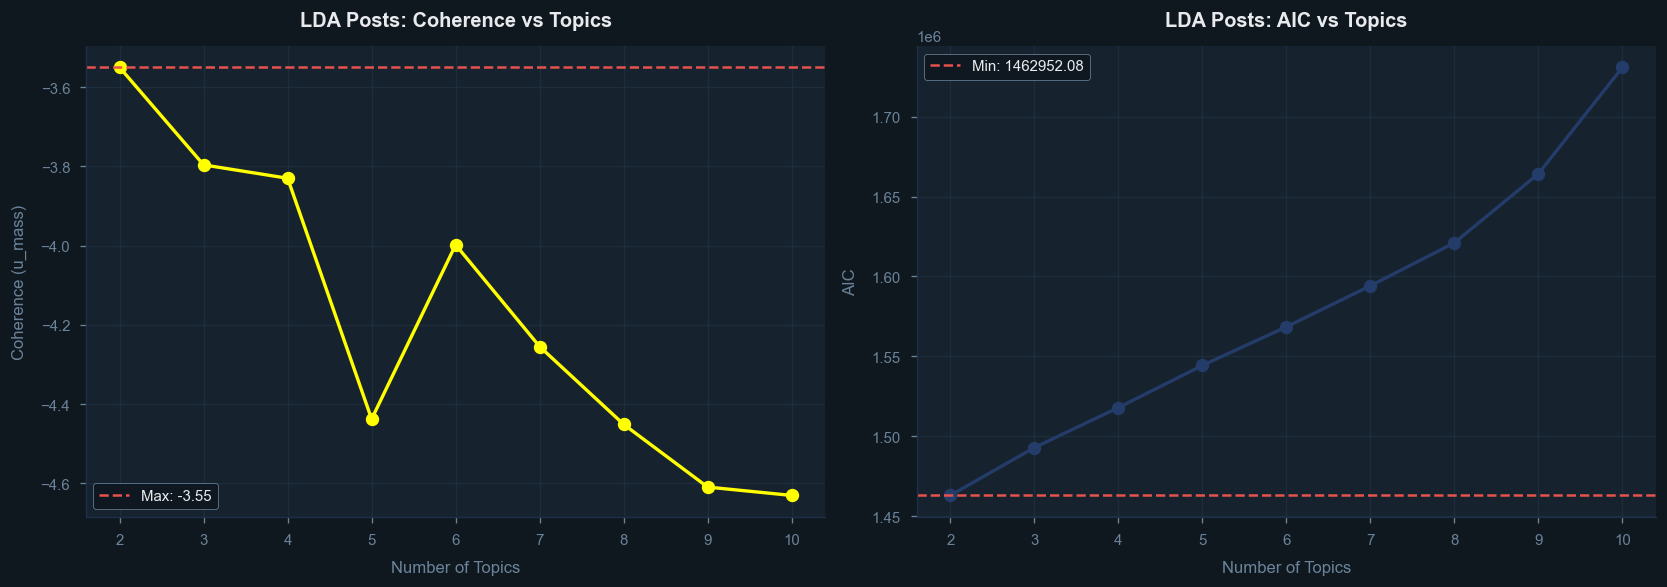

Optimal topics (max coherence): 2
Coherence: -3.5500


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG_DARK)

for ax, scores, ylabel, title, color in [
    (ax1, coherence_posts, 'Coherence (u_mass)', 'LDA Posts: Coherence vs Topics', '#FFFF00'),
    (ax2, aic_posts,       'AIC',                'LDA Posts: AIC vs Topics',        ACCENT),
]:
    ax.set_facecolor(BG_PANEL)
    ax.plot(list(topic_range), scores, marker='o', color=color, linewidth=2, markersize=7)
    best = max(scores) if 'Coherence' in ylabel else min(scores)
    ax.axhline(best, color=REPUBLICAN, lw=1.5, ls='--',
               label=f'{"Max" if "Coherence" in ylabel else "Min"}: {best:.2f}')
    ax.set_xlabel('Number of Topics', color=TEXT_MUTED, fontsize=10)
    ax.set_ylabel(ylabel, color=TEXT_MUTED, fontsize=10)
    ax.set_title(title, color=TEXT_PRIMARY, fontsize=12, fontweight='bold')
    ax.tick_params(colors=TEXT_MUTED)
    ax.legend(fontsize=9, facecolor=BG_DARK, edgecolor=TEXT_MUTED, labelcolor=TEXT_PRIMARY)

plt.tight_layout()
plt.show()

optimal_n_posts = list(topic_range)[np.argmax(coherence_posts)]
print(f'Optimal topics (max coherence): {optimal_n_posts}')
print(f'Coherence: {max(coherence_posts):.4f}')

### 2c. Train Final Model

In [7]:
print(f'Training final LDA (posts) with {optimal_n_posts} topics...')
t0 = time.time()
lda_posts = LdaModel(
    corpus=corpus_posts, id2word=dictionary_posts,
    num_topics=optimal_n_posts, random_state=42,
    passes=15, iterations=400,
    alpha='auto', eta='auto', per_word_topics=True,
)
print(f'Trained in {time.time()-t0:.1f}s')

cm_final = CoherenceModel(model=lda_posts, texts=tokenized_posts,
                          dictionary=dictionary_posts, coherence='u_mass')
print(f'Final coherence (u_mass): {cm_final.get_coherence():.4f}')

print('\n' + '='*80)
print('LDA TOPICS — POSTS (Top 12 Words)')
print('='*80)
lda_posts_labels = {}
for i in range(lda_posts.num_topics):
    words = [w for w, _ in lda_posts.show_topic(i, topn=12)]
    lda_posts_labels[i] = ' / '.join(words[:3])
    print(f'\nTopic {i}: {", ".join(words)}')

Training final LDA (posts) with 2 topics...
Trained in 140.5s
Final coherence (u_mass): -3.5374

LDA TOPICS — POSTS (Top 12 Words)

Topic 0: rally, walz, right, democrats, want, america, going, media, maga, see, left, win

Topic 1: campaign, debate, vance, presidential, voters, news, state, states, poll, democratic, party, former


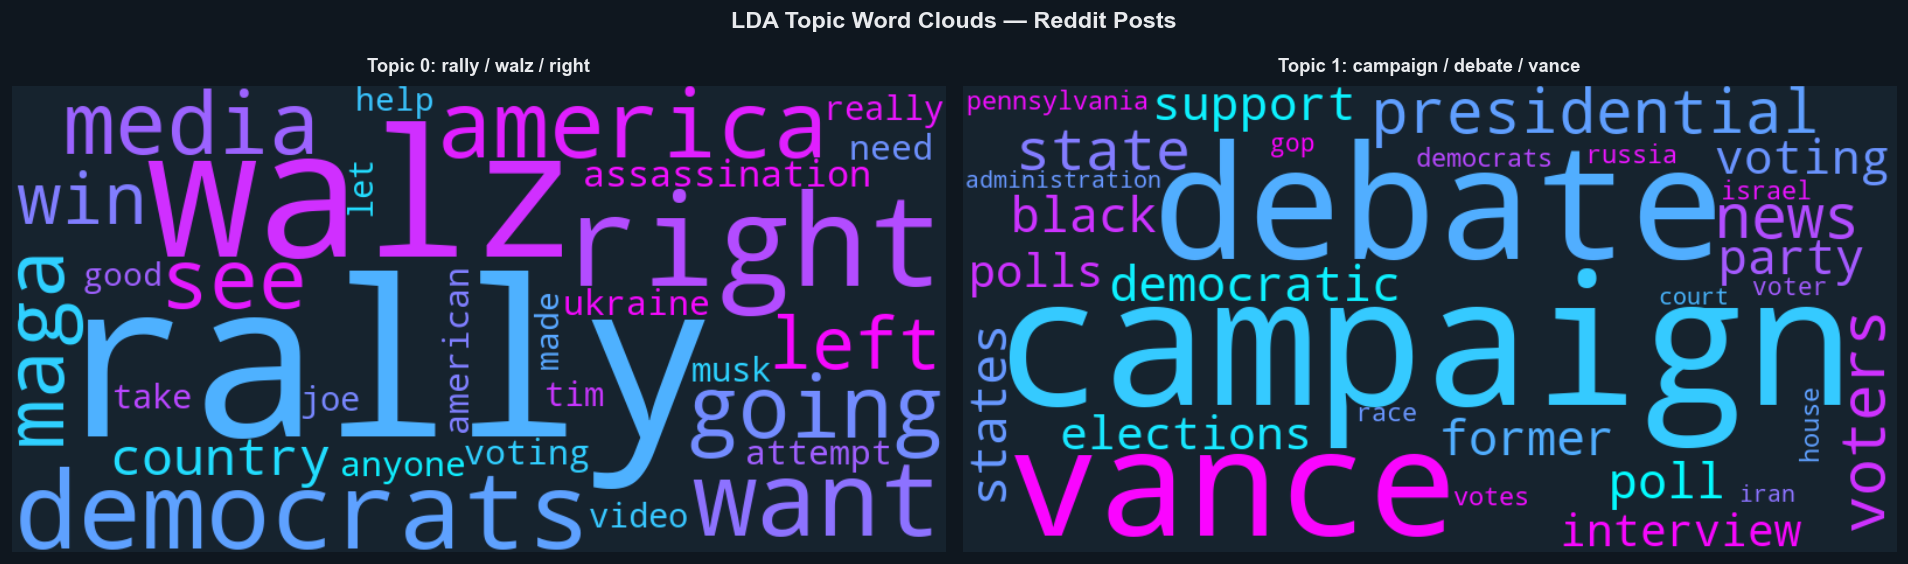

In [8]:
# ── Word clouds per topic ─────────────────────────────────────────────────────
n_topics = lda_posts.num_topics
n_cols   = 2
n_rows   = (n_topics + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
fig.patch.set_facecolor(BG_DARK)
axes = axes.flatten()

for topic_id in range(n_topics):
    topic_data   = lda_posts.show_topic(topic_id, topn=30)
    word_weights = {w: weight for w, weight in topic_data}

    wc = WordCloud(
        width=800, height=400,
        background_color='#16232e',
        colormap='cool',
        max_words=30,
        prefer_horizontal=0.9,
    ).generate_from_frequencies(word_weights)

    ax = axes[topic_id]
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Topic {topic_id}: {lda_posts_labels[topic_id]}',
                 color=TEXT_PRIMARY, fontweight='bold', fontsize=11, pad=8)

for i in range(n_topics, len(axes)):
    axes[i].axis('off')

fig.suptitle('LDA Topic Word Clouds — Reddit Posts',
             color=TEXT_PRIMARY, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2d. Topic Prominence Over Time

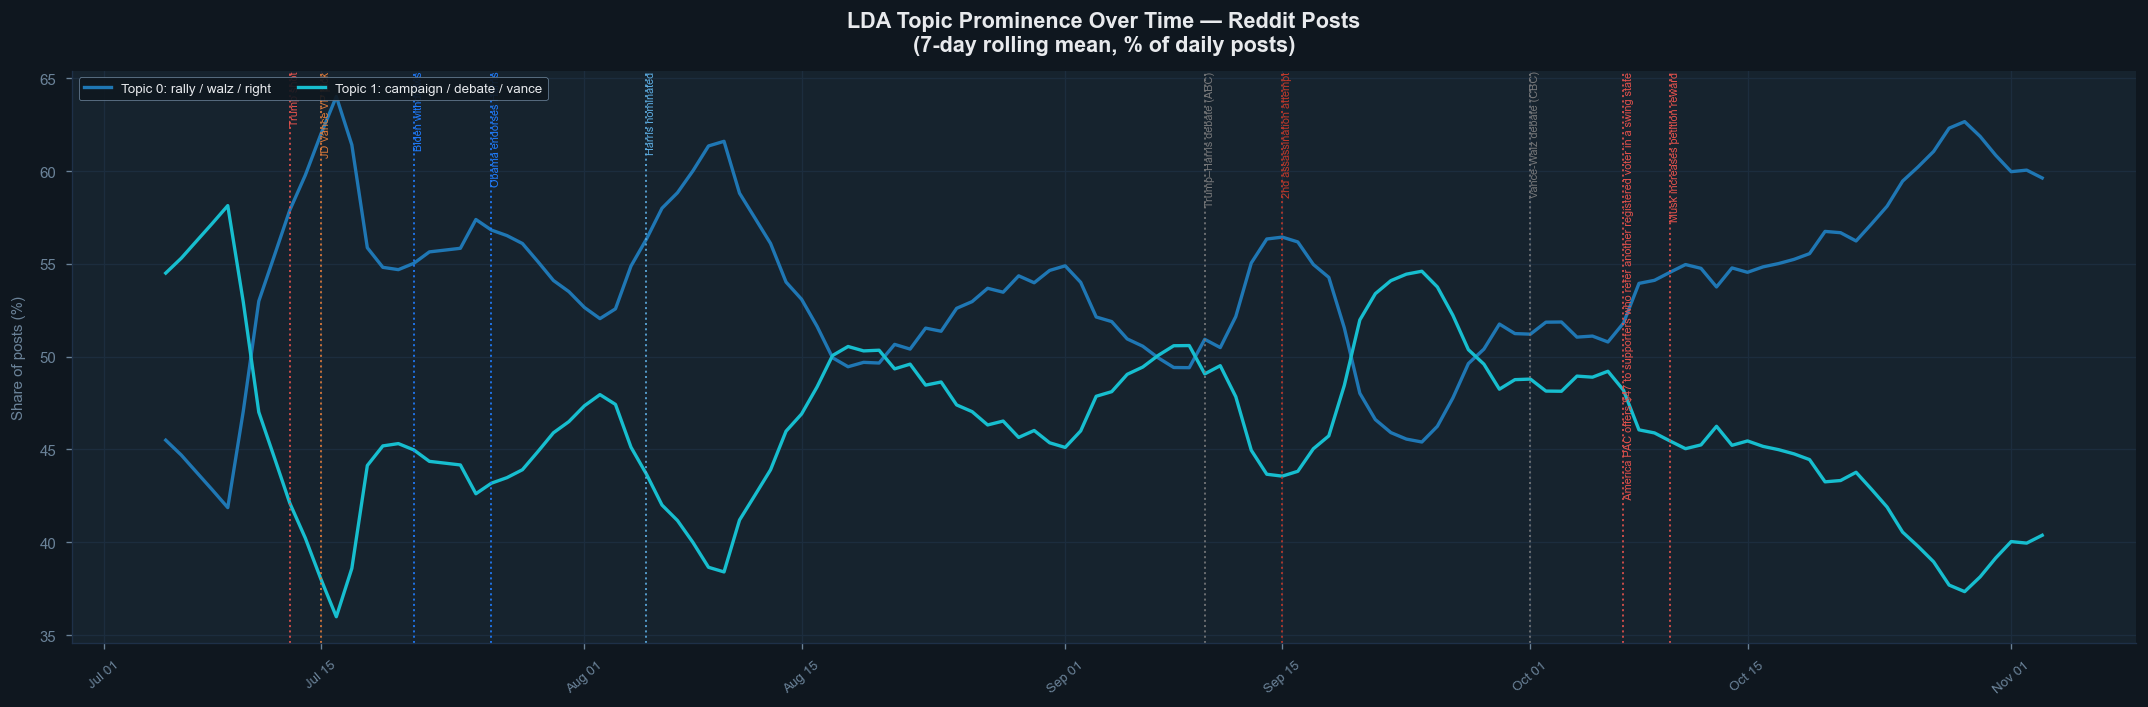

In [9]:
# ── Assign dominant topic per post ────────────────────────────────────────────
def dominant_topic(ldamodel, corpus_bow):
    result = []
    for doc in corpus_bow:
        dist = ldamodel.get_document_topics(doc)
        result.append(sorted(dist, key=lambda x: x[1], reverse=True)[0][0] if dist else -1)
    return result

posts_lda['lda_topic'] = dominant_topic(lda_posts, corpus_posts)

# Daily topic share
daily = (
    posts_lda.groupby(['date', 'lda_topic'])
    .size().reset_index(name='count')
)
daily_tot = posts_lda.groupby('date').size().reset_index(name='total')
daily = daily.merge(daily_tot, on='date')
daily['share'] = daily['count'] / daily['total'] * 100

topic_share = (
    daily.pivot(index='date', columns='lda_topic', values='share')
    .fillna(0)
    .sort_index()
)
topic_share.index = pd.to_datetime(topic_share.index)

topic_palette = plt.cm.tab10(np.linspace(0, 1, n_topics))

fig, ax = plt.subplots(figsize=(18, 6))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

for tid in topic_share.columns:
    smooth = topic_share[tid].rolling(7, center=True, min_periods=3).mean()
    ax.plot(topic_share.index, smooth,
            label=f'Topic {tid}: {lda_posts_labels[tid]}',
            linewidth=2, color=topic_palette[tid])

for lbl, date_str, color in EVENTS:
    dt = pd.Timestamp(date_str)
    ax.axvline(dt, color=color, lw=1.2, ls=':', alpha=0.85)
    ax.text(dt, ax.get_ylim()[1], f' {lbl}',
            color=color, fontsize=6.5, va='top', rotation=90)

ax.set_title('LDA Topic Prominence Over Time — Reddit Posts\n(7-day rolling mean, % of daily posts)',
             color=TEXT_PRIMARY, fontsize=13, fontweight='bold')
ax.set_ylabel('Share of posts (%)', color=TEXT_MUTED, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.tick_params(axis='x', rotation=40, colors=TEXT_MUTED, labelsize=8)
ax.tick_params(axis='y', colors=TEXT_MUTED)
ax.legend(fontsize=8, facecolor=BG_DARK, edgecolor=TEXT_MUTED,
          labelcolor=TEXT_PRIMARY, loc='upper left', ncol=2)
plt.tight_layout()
plt.show()

### 2e. Topic Distribution per Buzz Group

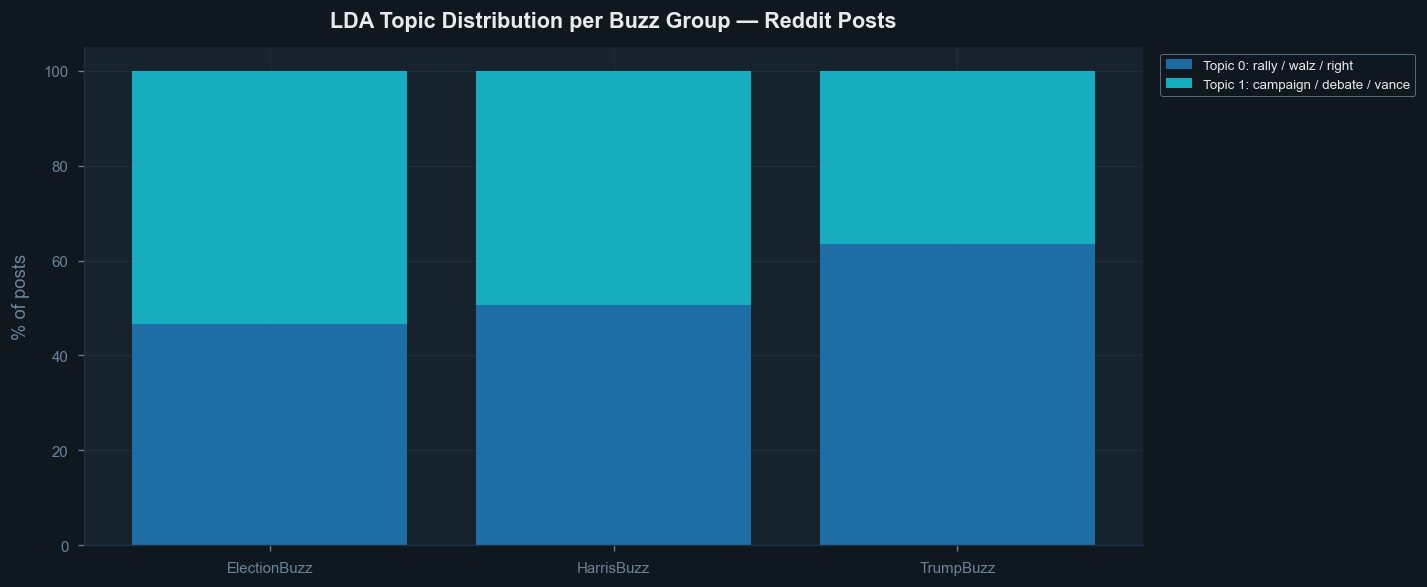

In [10]:
lda_buzz = posts_lda.groupby(['candidate', 'lda_topic']).size().unstack(fill_value=0)
lda_buzz_pct = lda_buzz.div(lda_buzz.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

bottom = np.zeros(len(lda_buzz_pct))
for i, col in enumerate(lda_buzz_pct.columns):
    ax.bar(lda_buzz_pct.index, lda_buzz_pct[col], bottom=bottom,
           label=f'Topic {col}: {lda_posts_labels[col]}',
           color=topic_palette[i], edgecolor='none', alpha=0.9)
    bottom += lda_buzz_pct[col].values

ax.set_ylabel('% of posts', color=TEXT_MUTED)
ax.set_title('LDA Topic Distribution per Buzz Group — Reddit Posts',
             color=TEXT_PRIMARY, fontsize=13, fontweight='bold')
ax.tick_params(colors=TEXT_MUTED)
ax.legend(fontsize=8, facecolor=BG_DARK, edgecolor=TEXT_MUTED,
          labelcolor=TEXT_PRIMARY, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 3. LDA Topic Modeling — Comments

Comments are where Reddit users **react and discuss** rather than just share links. We repeat LDA on a stratified sample of 100k comments (equal share per buzz group) to see whether the topics mirror posts or diverge — e.g., posts may frame policy while comments drive emotional reactions.

We use the same number of topics as posts to allow direct comparison.

In [11]:
print('Building LDA dictionary & corpus for comments...')
tokenized_comments = comments_lda['tokens_lda'].tolist()

dictionary_comments = corpora.Dictionary(tokenized_comments)
print(f'Original vocabulary: {len(dictionary_comments):,}')
dictionary_comments.filter_extremes(no_below=5, no_above=0.5)
print(f'Filtered vocabulary: {len(dictionary_comments):,}')

corpus_comments = [dictionary_comments.doc2bow(doc) for doc in tokenized_comments]
print(f'Corpus: {len(corpus_comments):,} comments')

Building LDA dictionary & corpus for comments...
Original vocabulary: 46,783
Filtered vocabulary: 17,307
Corpus: 99,950 comments


In [12]:
print(f'Training comments LDA with {optimal_n_posts} topics (same as posts for comparison)...')
t0 = time.time()
lda_comments = LdaModel(
    corpus=corpus_comments, id2word=dictionary_comments,
    num_topics=optimal_n_posts, random_state=42,
    passes=15, iterations=400,
    alpha='auto', eta='auto', per_word_topics=True,
)
print(f'Trained in {time.time()-t0:.1f}s')

print('\n' + '='*80)
print('LDA TOPICS — COMMENTS (Top 12 Words)')
print('='*80)
lda_comm_labels = {}
for i in range(lda_comments.num_topics):
    words = [w for w, _ in lda_comments.show_topic(i, topn=12)]
    lda_comm_labels[i] = ' / '.join(words[:3])
    print(f'\nTopic {i}: {", ".join(words)}')

Training comments LDA with 2 topics (same as posts for comparison)...
Trained in 208.5s

LDA TOPICS — COMMENTS (Top 12 Words)

Topic 0: republicans, going, vance, right, want, maga, party, really, see, much, gop, win

Topic 1: please, russia, putin, war, concerns, government, court, ukraine, message, action, questions, rules


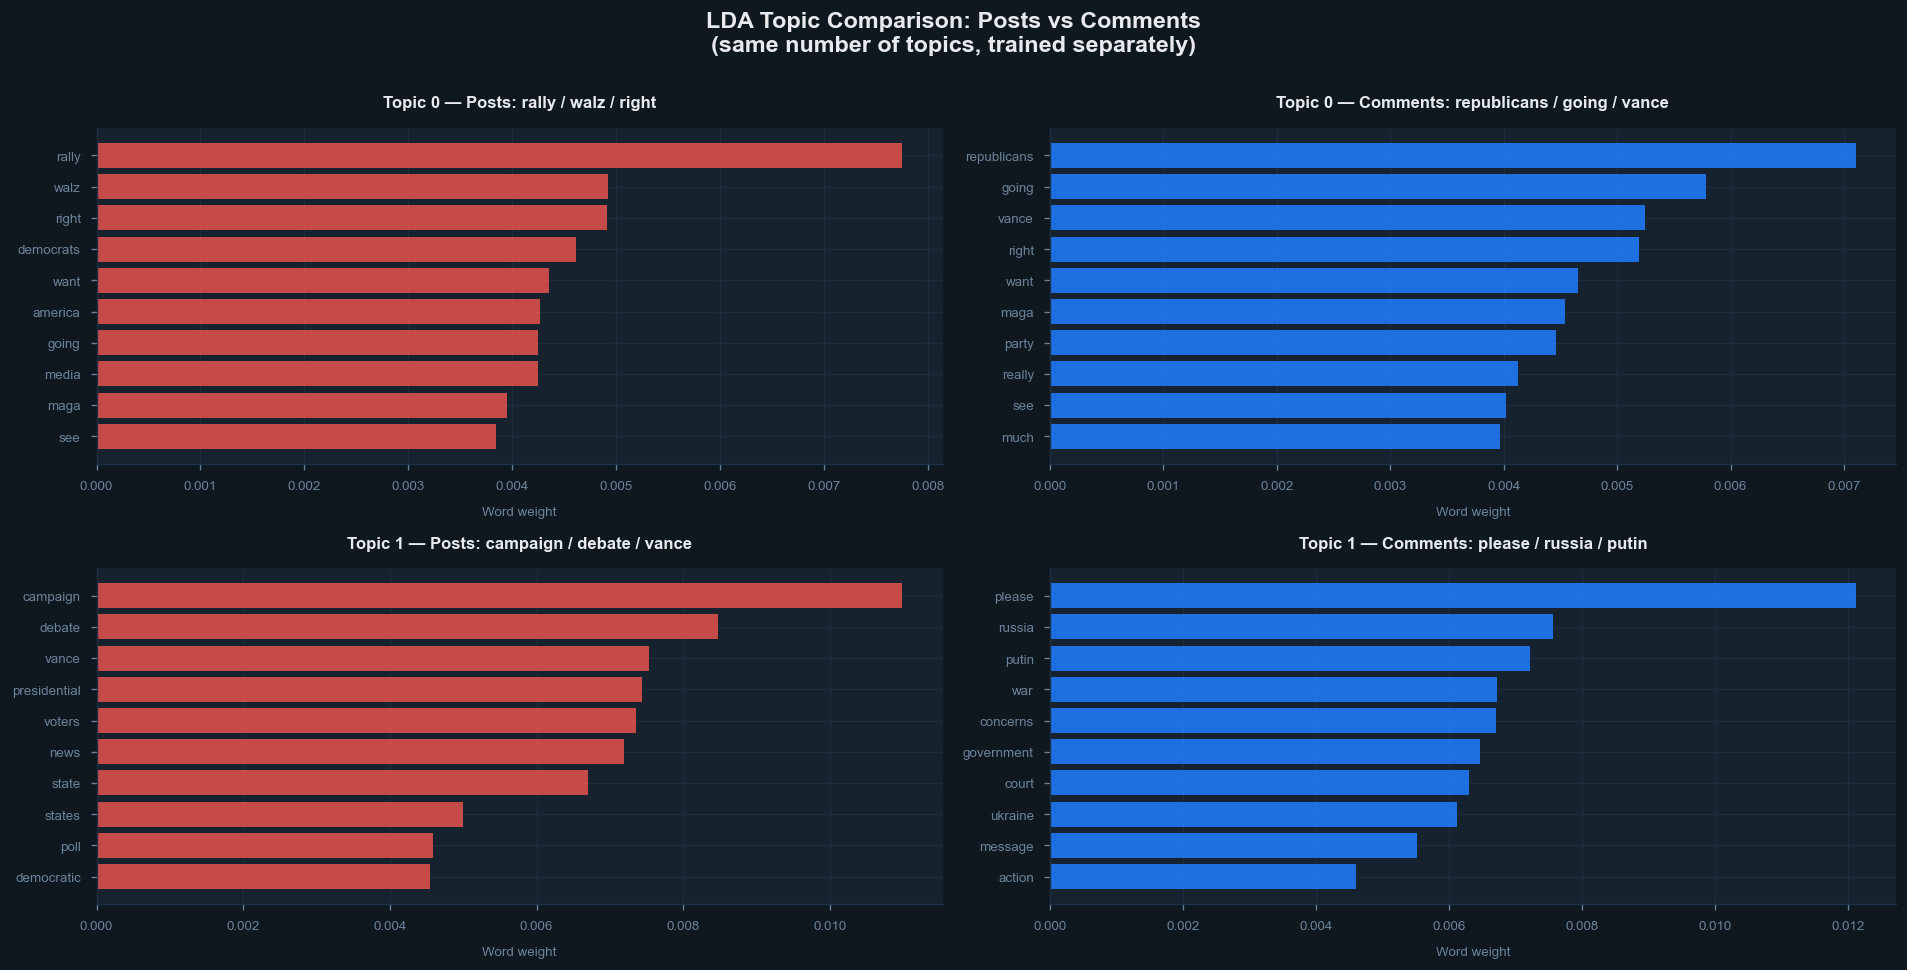

In [13]:
# ── Side-by-side top-word bar charts: posts vs comments ───────────────────────
TOP_WORDS = 10

fig, axes = plt.subplots(n_topics, 2, figsize=(16, 4 * n_topics))
fig.patch.set_facecolor(BG_DARK)

for tid in range(n_topics):
    for col_idx, (model, label_map, title_suffix) in enumerate([
        (lda_posts,    lda_posts_labels, 'Posts'),
        (lda_comments, lda_comm_labels,  'Comments'),
    ]):
        ax = axes[tid][col_idx]
        ax.set_facecolor(BG_PANEL)
        topic_words = model.show_topic(tid, topn=TOP_WORDS)
        words, weights = zip(*topic_words)
        color = REPUBLICAN if col_idx == 0 else DEMOCRAT
        ax.barh(list(words)[::-1], list(weights)[::-1],
                color=color, alpha=0.85, edgecolor='none')
        ax.set_title(f'Topic {tid} — {title_suffix}: {label_map[tid]}',
                     color=TEXT_PRIMARY, fontsize=10, fontweight='bold')
        ax.tick_params(labelsize=8, colors=TEXT_MUTED)
        ax.set_xlabel('Word weight', color=TEXT_MUTED, fontsize=8)

fig.suptitle('LDA Topic Comparison: Posts vs Comments\n(same number of topics, trained separately)',
             color=TEXT_PRIMARY, fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

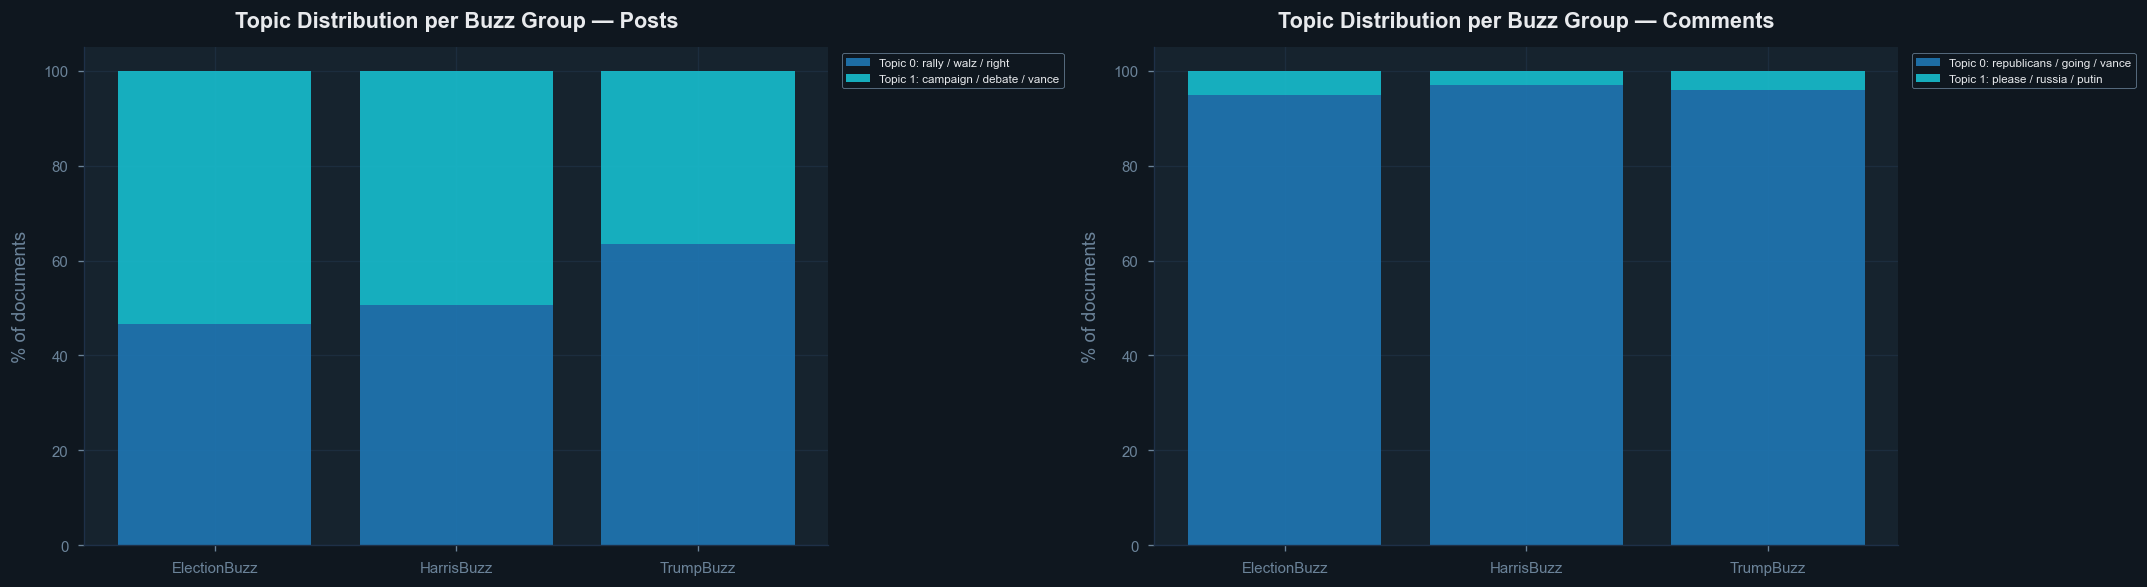

In [14]:
# ── Comment topic distribution per buzz group ─────────────────────────────────
assert 'candidate' in comments_lda.columns, (
    "'candidate' column missing from comments_lda — restart the kernel "
    "and run all cells again (Kernel > Restart & Run All)."
)

comments_lda['lda_topic'] = dominant_topic(lda_comments, corpus_comments)

comm_buzz = comments_lda.groupby(['candidate', 'lda_topic']).size().unstack(fill_value=0)
comm_buzz_pct = comm_buzz.div(comm_buzz.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.patch.set_facecolor(BG_DARK)

for ax, pct_df, title_suffix, labels in [
    (axes[0], lda_buzz_pct,  'Posts',    lda_posts_labels),
    (axes[1], comm_buzz_pct, 'Comments', lda_comm_labels),
]:
    ax.set_facecolor(BG_PANEL)
    bottom = np.zeros(len(pct_df))
    for i, col in enumerate(pct_df.columns):
        ax.bar(pct_df.index, pct_df[col], bottom=bottom,
               label=f'Topic {col}: {labels[col]}',
               color=topic_palette[i], edgecolor='none', alpha=0.9)
        bottom += pct_df[col].values
    ax.set_ylabel('% of documents', color=TEXT_MUTED)
    ax.set_title(f'Topic Distribution per Buzz Group — {title_suffix}',
                 color=TEXT_PRIMARY, fontweight='bold')
    ax.tick_params(colors=TEXT_MUTED)
    ax.legend(fontsize=7, facecolor=BG_DARK, edgecolor=TEXT_MUTED,
              labelcolor=TEXT_PRIMARY, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 4. Subreddit Echo Chambers

Reddit is uniquely partitioned into **subreddits** that act as political echo chambers. The top subreddits in our data (r/politics, r/conservative, r/democrats, r/trump, r/republican) have known political leanings.

By mapping LDA topics onto subreddits we can:
1. Verify that subreddit-level topic distributions align with expected political leanings
2. Identify which subreddits discuss the **same topics** vs which issues are **community-exclusive**
3. Measure **echo-chamber strength** via topic entropy — low entropy = concentrated in few topics = stronger echo chamber

In [15]:
# Keep top-N subreddits by post count
TOP_SUBREDDITS = 7
top_subs = posts_lda['subreddit'].value_counts().head(TOP_SUBREDDITS).index.tolist()
print('Top subreddits by post count:')
print(posts_lda['subreddit'].value_counts().head(TOP_SUBREDDITS).to_string())

sub_df = posts_lda[posts_lda['subreddit'].isin(top_subs)].copy()

# Topic distribution per subreddit
sub_topic     = sub_df.groupby(['subreddit', 'lda_topic']).size().unstack(fill_value=0)
sub_topic_pct = sub_topic.div(sub_topic.sum(axis=1), axis=0) * 100
sub_topic_pct = sub_topic_pct.loc[top_subs]   # preserve rank order

print('\nTopic distribution by subreddit (%):')
print(sub_topic_pct.round(1).to_string())

Top subreddits by post count:
subreddit
politics        37625
conservative    20100
democrats       12290
trump            7794
republican       3817
worldnews        2988
liberal           832

Topic distribution by subreddit (%):
lda_topic        0     1
subreddit               
politics      44.7  55.3
conservative  59.1  40.9
democrats     60.2  39.8
trump         82.7  17.3
republican    68.2  31.8
worldnews     36.1  63.9
liberal       75.6  24.4


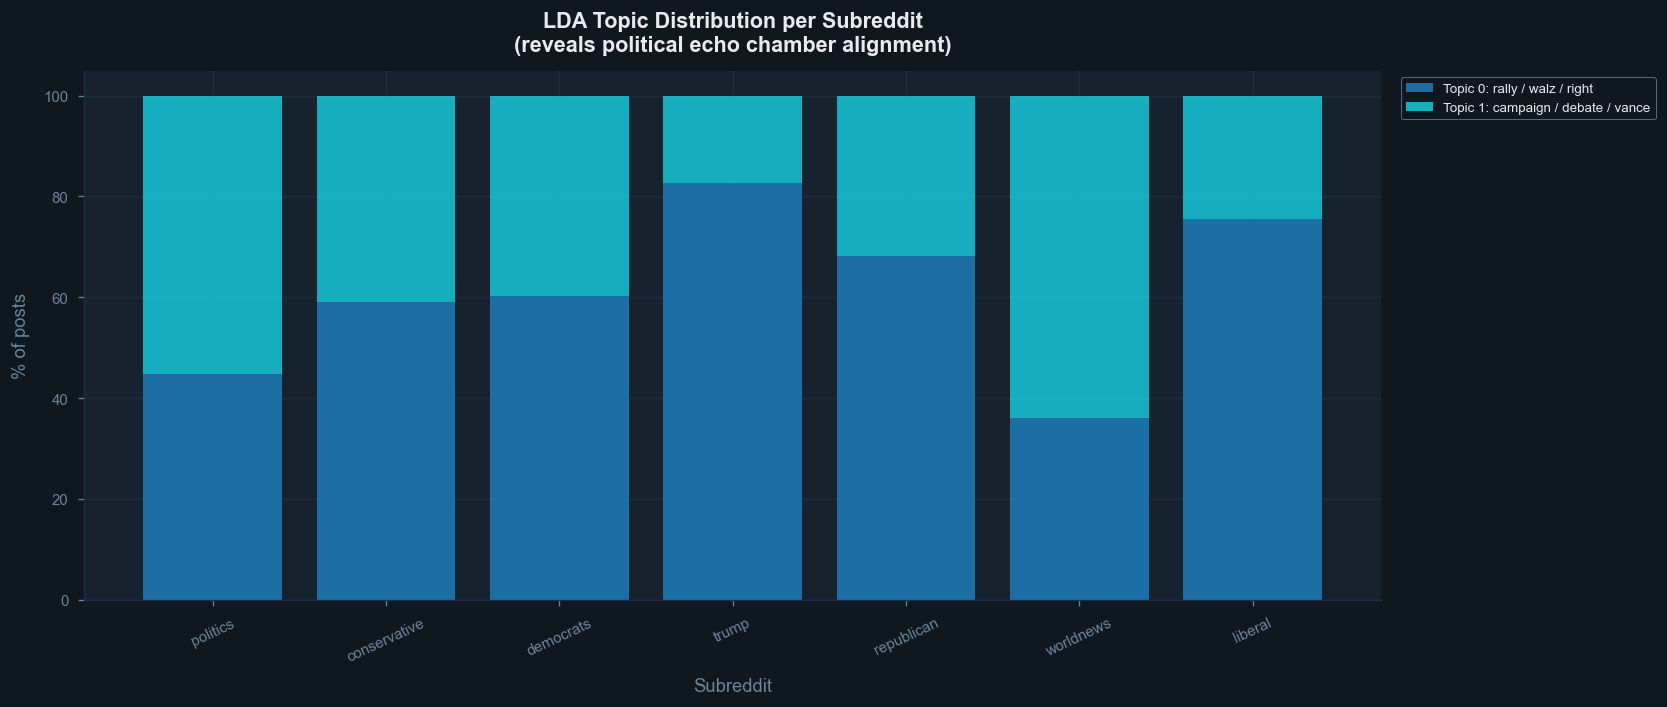

In [16]:
# ── Stacked bar: topic mix per subreddit ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

bottom = np.zeros(len(sub_topic_pct))
for i, col in enumerate(sub_topic_pct.columns):
    ax.bar(sub_topic_pct.index, sub_topic_pct[col], bottom=bottom,
           label=f'Topic {col}: {lda_posts_labels[col]}',
           color=topic_palette[i], edgecolor='none', alpha=0.9)
    bottom += sub_topic_pct[col].values

ax.set_ylabel('% of posts', color=TEXT_MUTED)
ax.set_xlabel('Subreddit', color=TEXT_MUTED)
ax.set_title('LDA Topic Distribution per Subreddit\n(reveals political echo chamber alignment)',
             color=TEXT_PRIMARY, fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=25, colors=TEXT_MUTED)
ax.tick_params(axis='y', colors=TEXT_MUTED)
ax.legend(fontsize=8, facecolor=BG_DARK, edgecolor=TEXT_MUTED,
          labelcolor=TEXT_PRIMARY, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

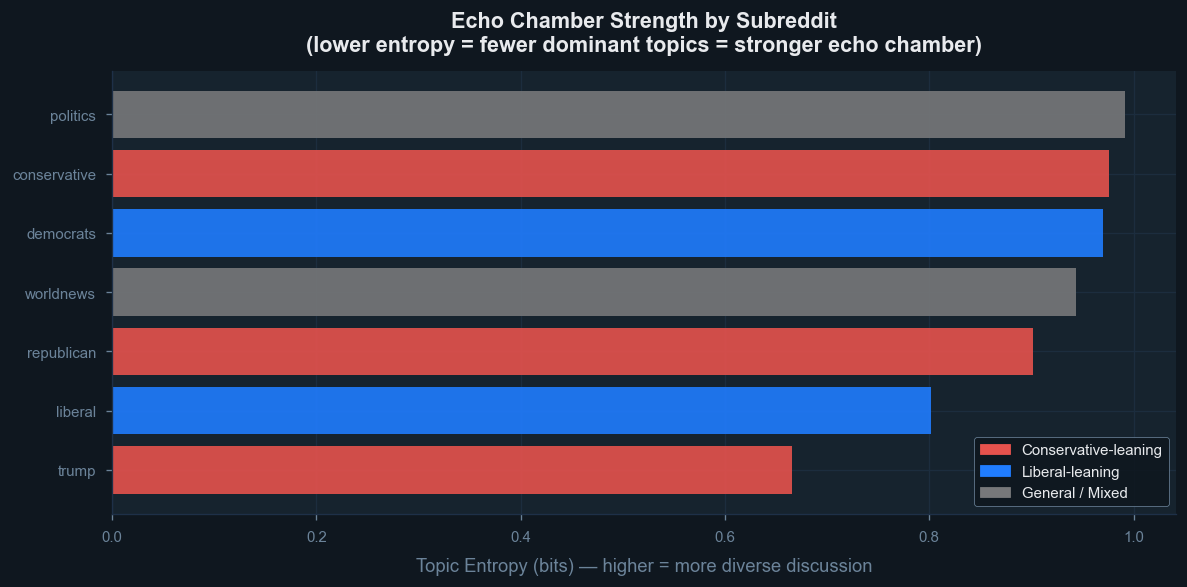


Entropy scores (bits):
  trump                0.666 bits
  liberal              0.802 bits
  republican           0.902 bits
  worldnews            0.944 bits
  democrats            0.970 bits
  conservative         0.976 bits
  politics             0.992 bits


In [17]:
# ── Topic entropy per subreddit: echo-chamber diversity score ─────────────────
# Low entropy  = concentrated in few topics = stronger echo chamber
# High entropy = diverse topics             = more open discussion
entropies = {}
for sub in top_subs:
    probs = sub_topic_pct.loc[sub].values / 100
    probs = np.where(probs > 0, probs, 1e-9)   # avoid log(0)
    entropies[sub] = scipy_entropy(probs, base=2)

entropy_df = pd.Series(entropies).sort_values(ascending=True)

# Colour-code by known political leaning
SUB_COLORS = {
    'politics':     NEUTRAL,
    'conservative': REPUBLICAN,
    'democrats':    DEMOCRAT,
    'trump':        REPUBLICAN,
    'republican':   REPUBLICAN,
    'worldnews':    NEUTRAL,
    'liberal':      DEMOCRAT,
}
bar_colors = [SUB_COLORS.get(s, NEUTRAL) for s in entropy_df.index]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

ax.barh(entropy_df.index, entropy_df.values, color=bar_colors, alpha=0.9, edgecolor='none')
ax.set_xlabel('Topic Entropy (bits) — higher = more diverse discussion', color=TEXT_MUTED)
ax.set_title('Echo Chamber Strength by Subreddit\n(lower entropy = fewer dominant topics = stronger echo chamber)',
             color=TEXT_PRIMARY, fontsize=13, fontweight='bold')
ax.tick_params(labelsize=9, colors=TEXT_MUTED)

legend_handles = [
    mpatches.Patch(color=REPUBLICAN, label='Conservative-leaning'),
    mpatches.Patch(color=DEMOCRAT,   label='Liberal-leaning'),
    mpatches.Patch(color=NEUTRAL,    label='General / Mixed'),
]
ax.legend(handles=legend_handles, facecolor=BG_DARK, edgecolor=TEXT_MUTED,
          labelcolor=TEXT_PRIMARY, fontsize=9)

plt.tight_layout()
plt.show()

print('\nEntropy scores (bits):')
for sub, ent in entropy_df.items():
    print(f'  {sub:<20} {ent:.3f} bits')